# Final Analysis Training

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_losses = pd.read_csv("ave_losses.csv")
df_val_maes = pd.read_csv("val_maes.csv")

In [3]:
architectures = [
    "MGT",
    "PIMGT_Internal_Full",
    "PIMGT_Internal_Partial",
    "PIMGT_External_Full",
    "PIMGT_External_Partial"
]
seeds = ["25", "42", "79"]


In [4]:
# For ave_losses
losses_by_arch = {arch: df_losses[[col for col in df_losses.columns if col.startswith(f"{arch}_")]] for arch in architectures}
losses_by_seed = {seed: df_losses[[col for col in df_losses.columns if f"_seed{seed}" in col]] for seed in seeds}

# For val_maes
valmaes_by_arch = {arch: df_val_maes[[col for col in df_val_maes.columns if col.startswith(f"{arch}_")]] for arch in architectures}
valmaes_by_seed = {seed: df_val_maes[[col for col in df_val_maes.columns if f"_seed{seed}" in col]] for seed in seeds}


In [5]:
def plot_generic_lines(df, title, ylabel, folder, figsize=(10, 6)):
    os.makedirs(folder, exist_ok=True)

    plt.figure(figsize=figsize)
    for col in df.columns:
        plt.plot(df.index, df[col], label=col)

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)

    # Lock y-axis ranges based on metric type
    if "loss" in folder.lower():
        plt.ylim(0.2, 0.6)
    elif "val_mae" in folder.lower() or "valmae" in folder.lower():
        plt.ylim(0.15, 0.35)

    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(folder, f"{title}.png"), bbox_inches='tight')
    plt.show()


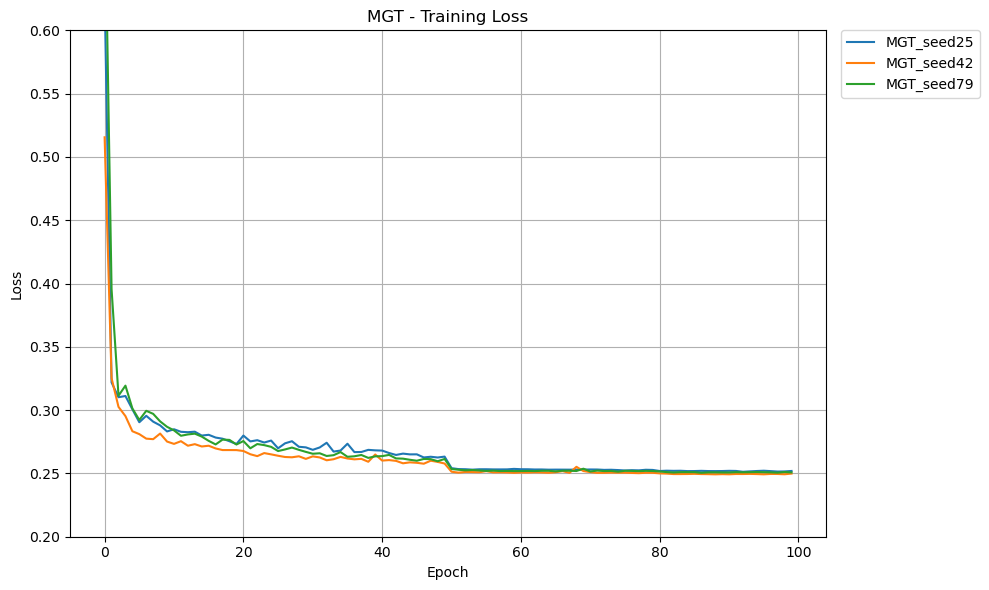

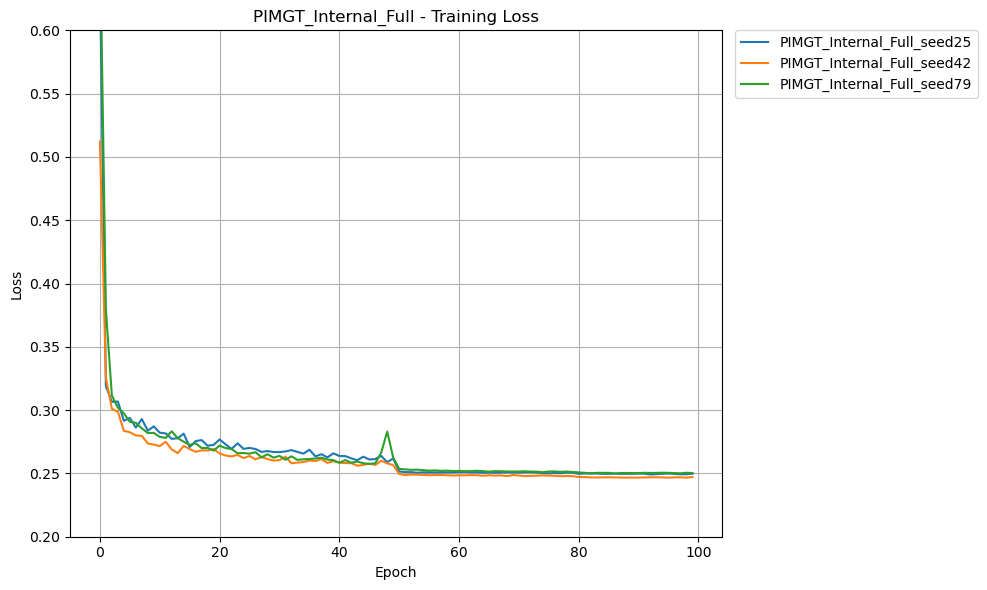

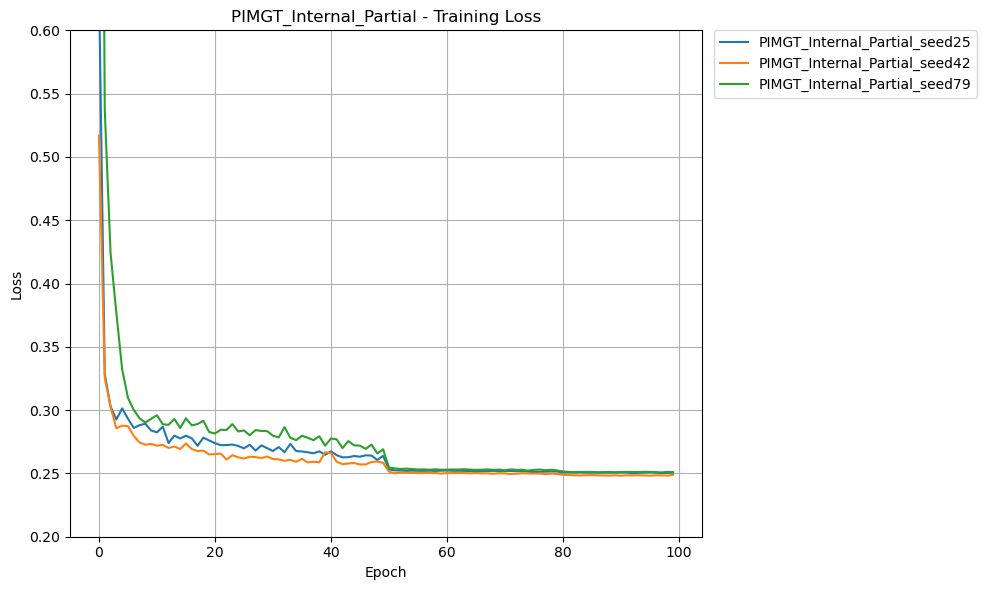

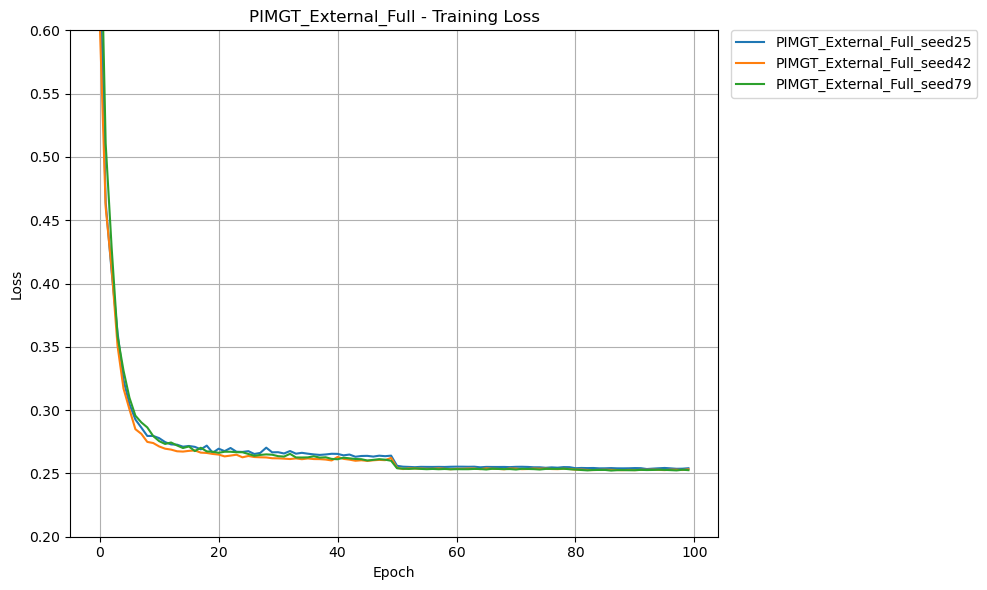

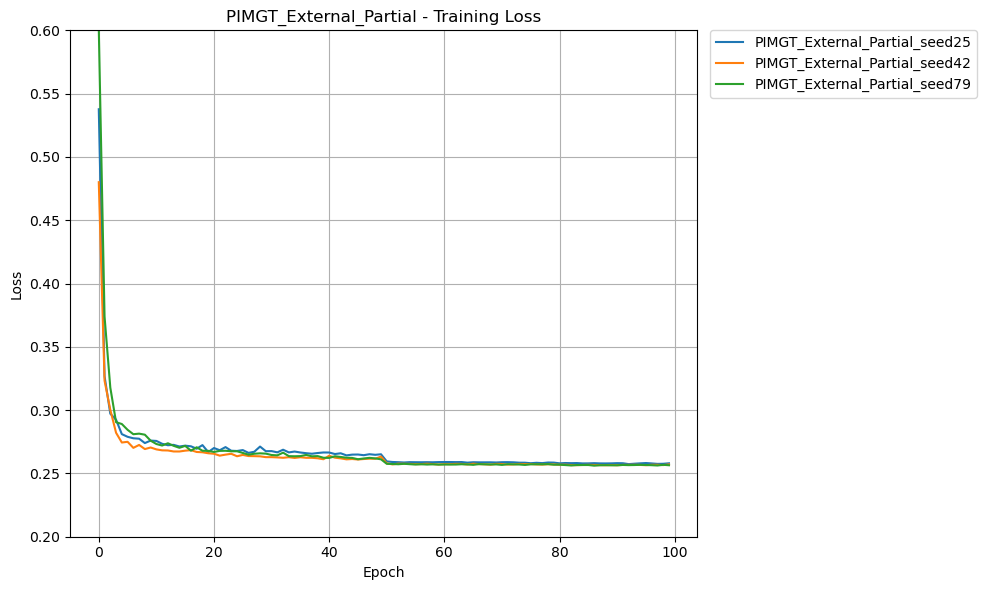

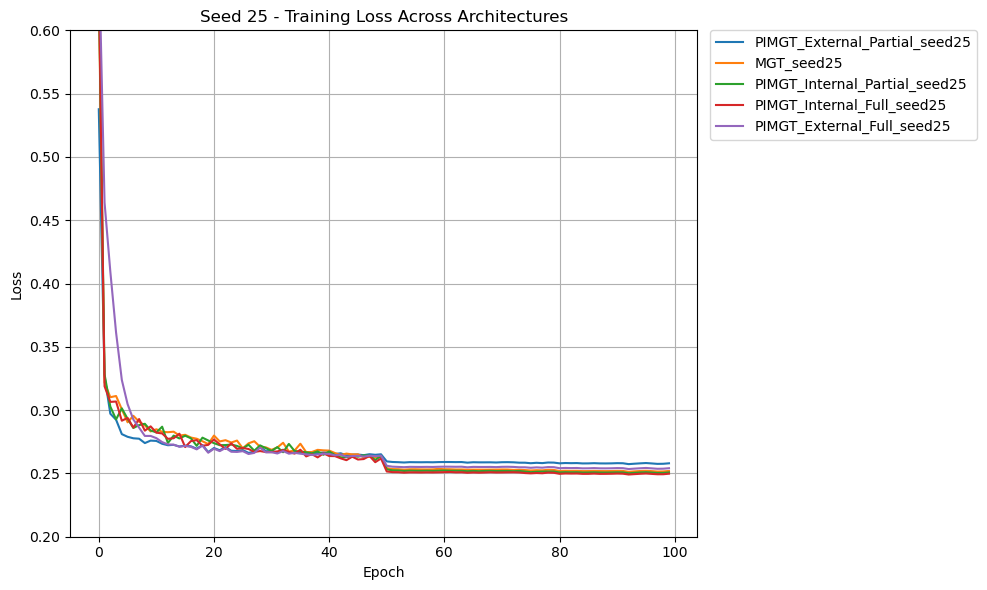

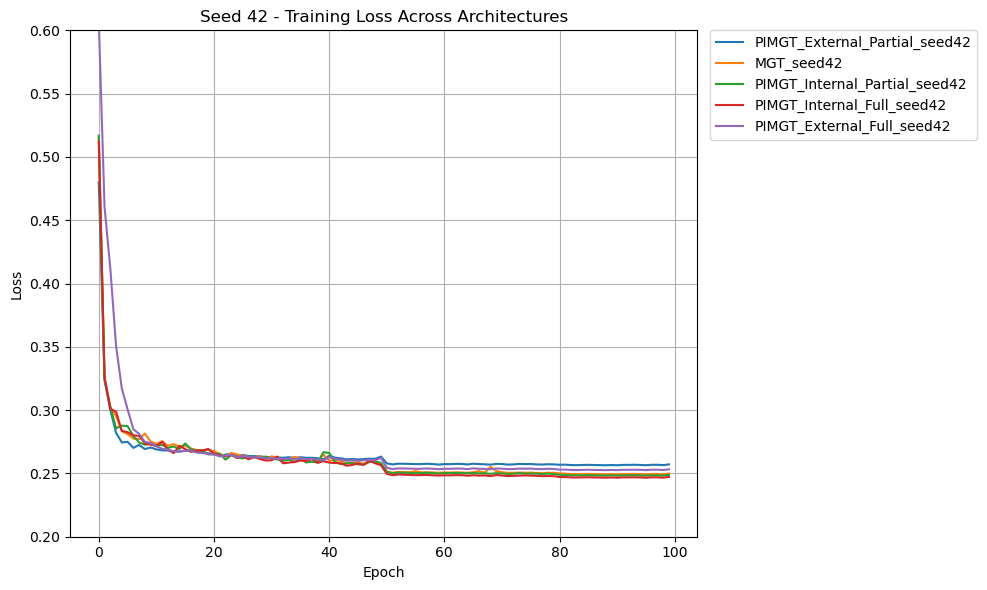

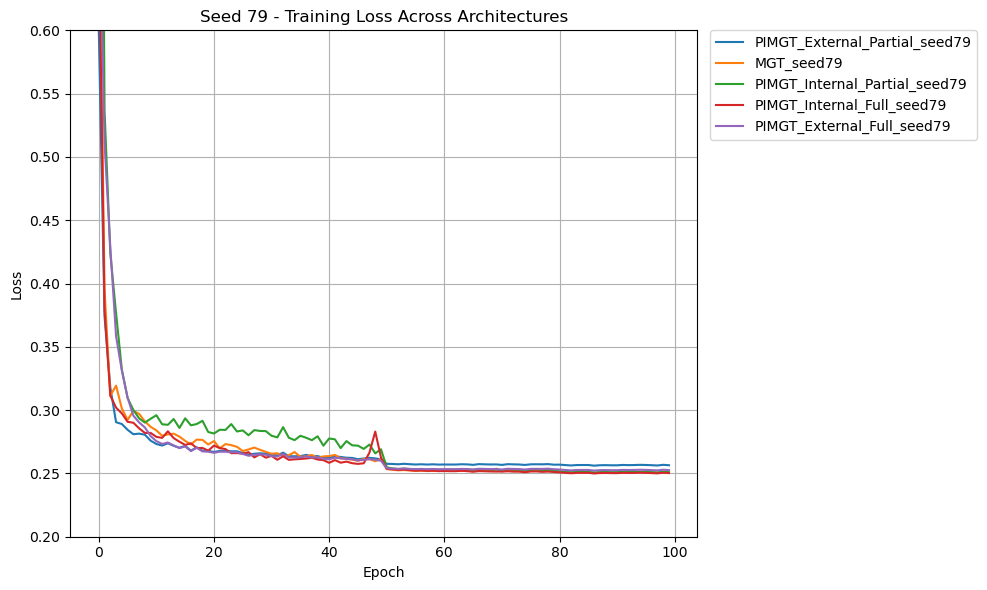

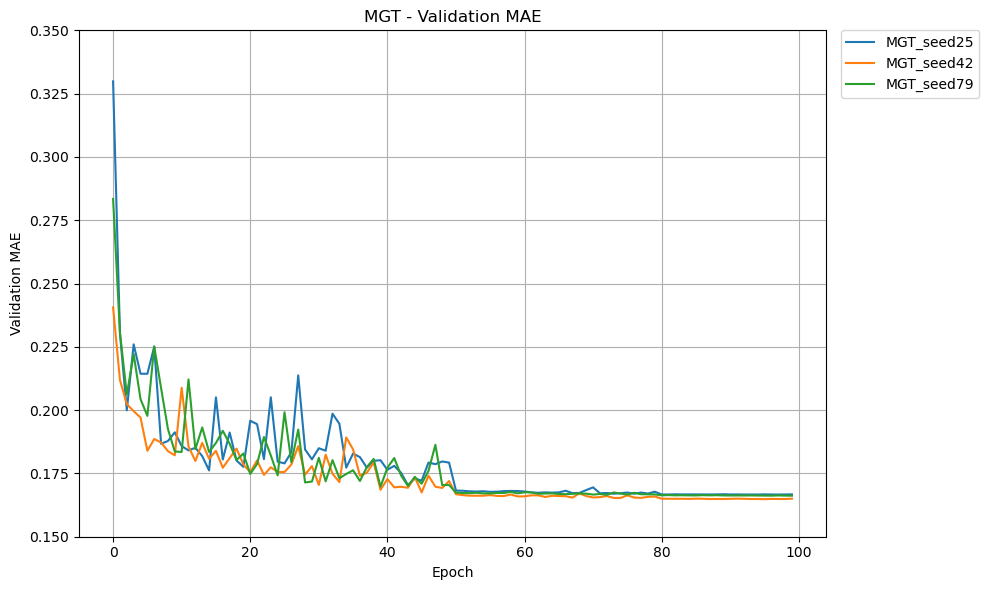

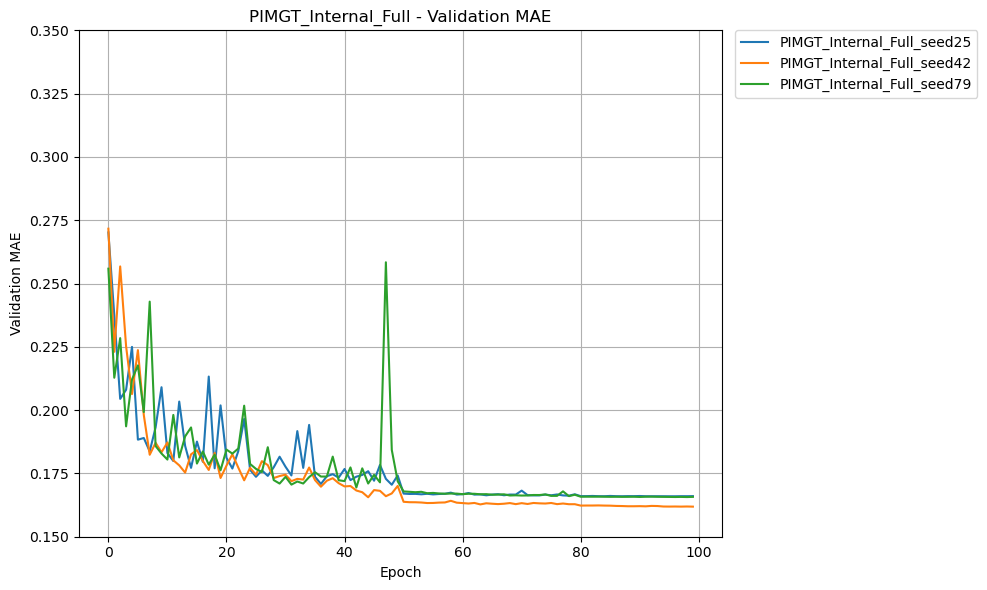

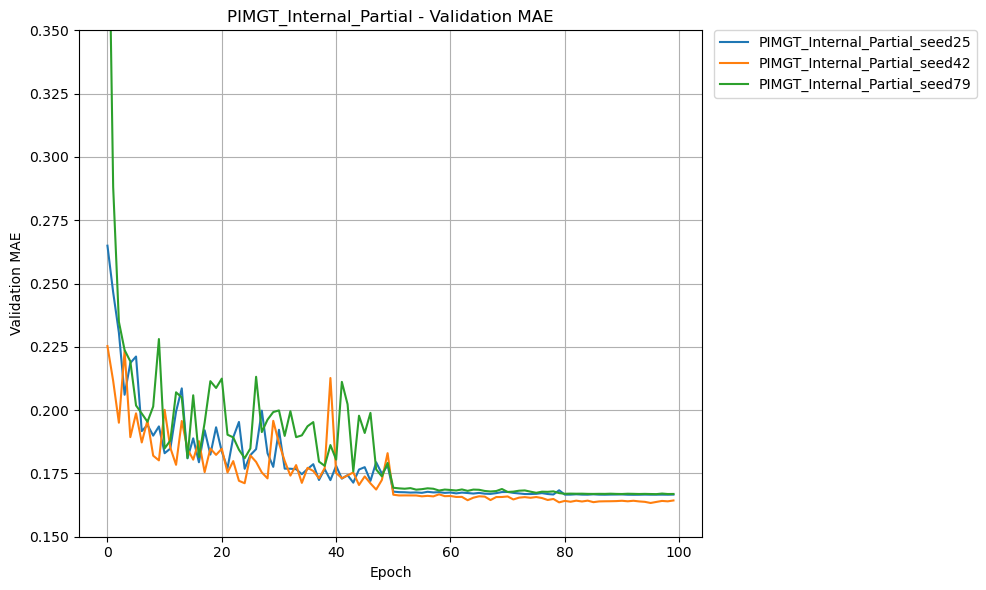

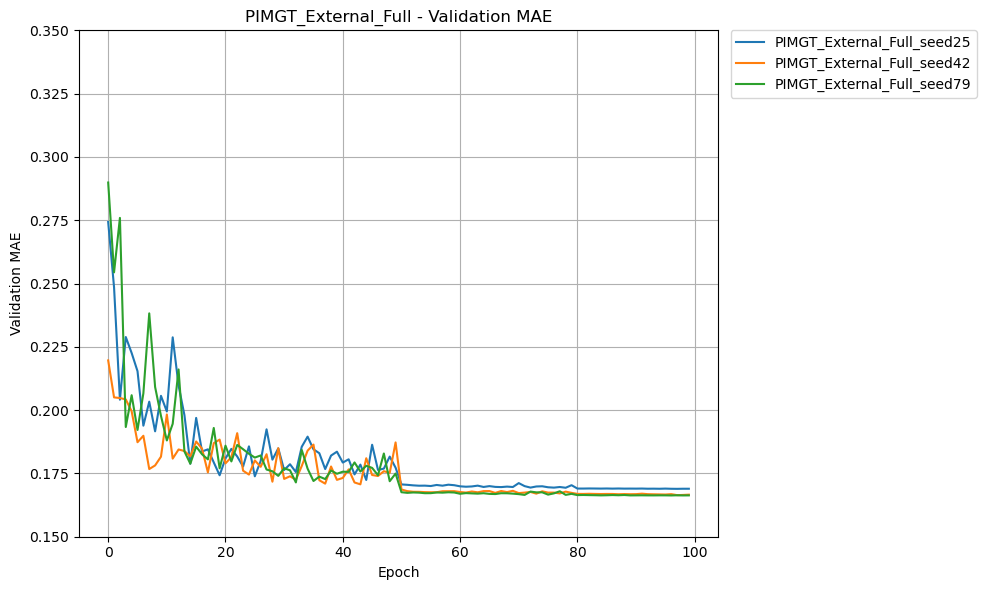

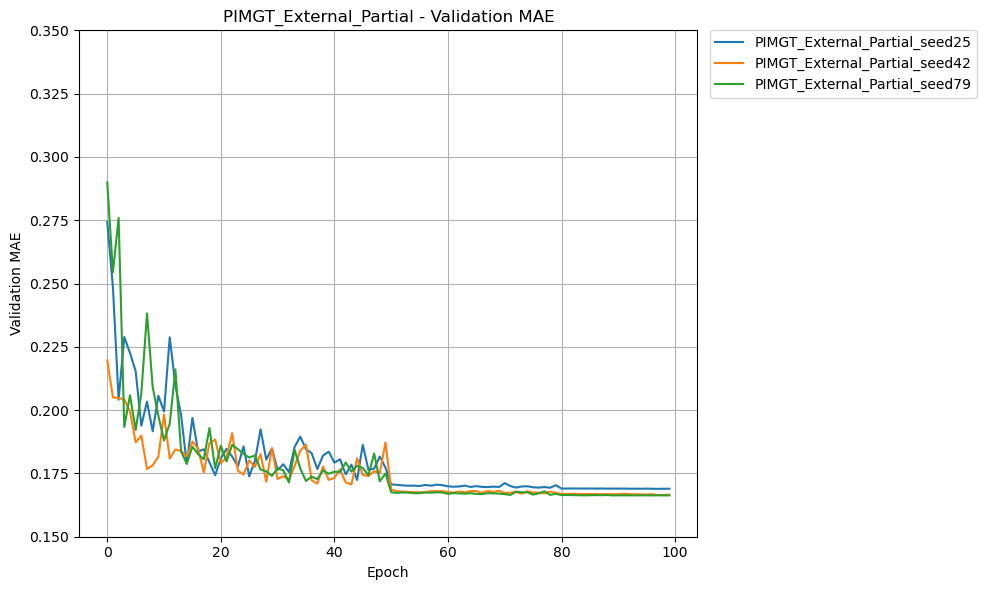

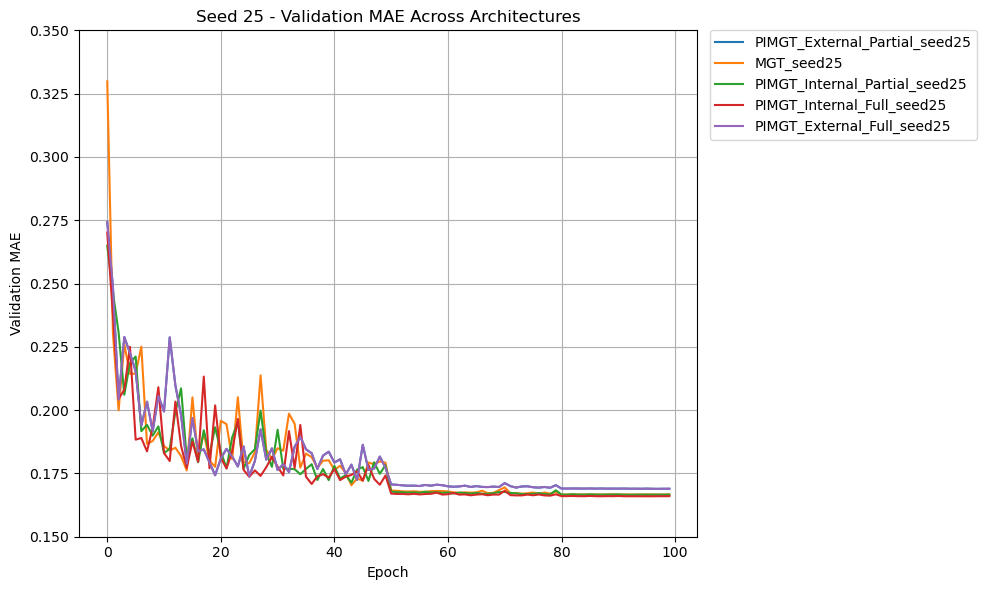

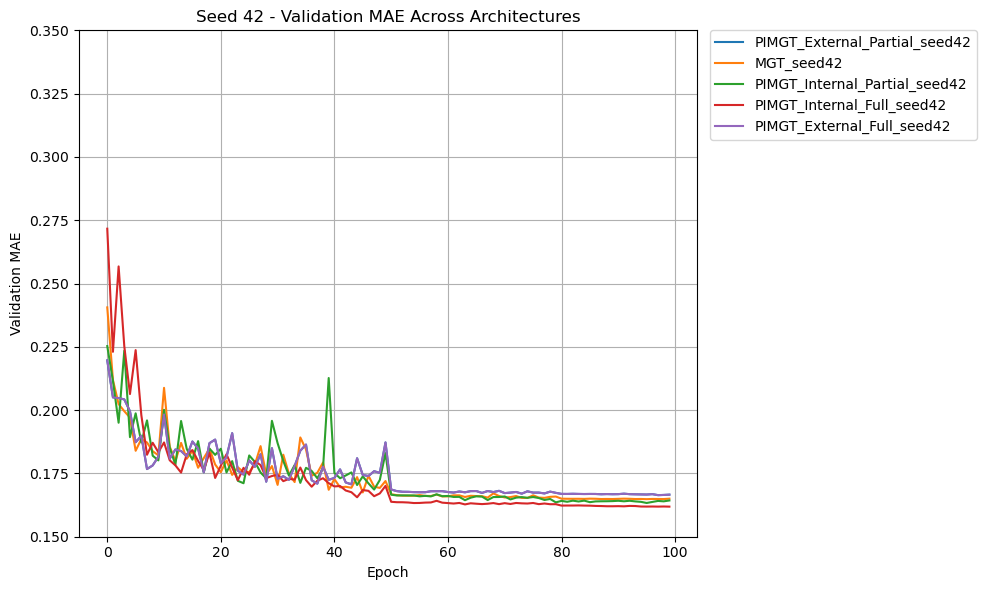

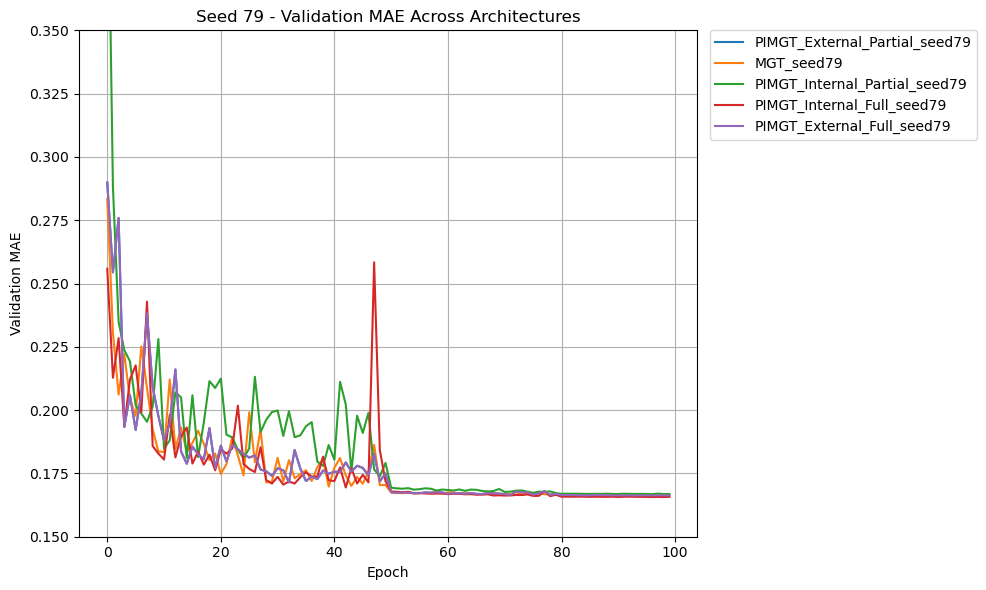

In [6]:
# Loss plots by architecture
for arch, df_sub in losses_by_arch.items():
    plot_generic_lines(df_sub, f"{arch} - Training Loss", "Loss", "losses")

# Loss plots by seed
for seed, df_sub in losses_by_seed.items():
    plot_generic_lines(df_sub, f"Seed {seed} - Training Loss Across Architectures", "Loss", "losses")

# Val MAE plots by architecture
for arch, df_sub in valmaes_by_arch.items():
    plot_generic_lines(df_sub, f"{arch} - Validation MAE", "Validation MAE", "val_maes")

# Val MAE plots by seed
for seed, df_sub in valmaes_by_seed.items():
    plot_generic_lines(df_sub, f"Seed {seed} - Validation MAE Across Architectures", "Validation MAE", "val_maes")